## Análisis de Datos de Spotify México 2020 con SQLite

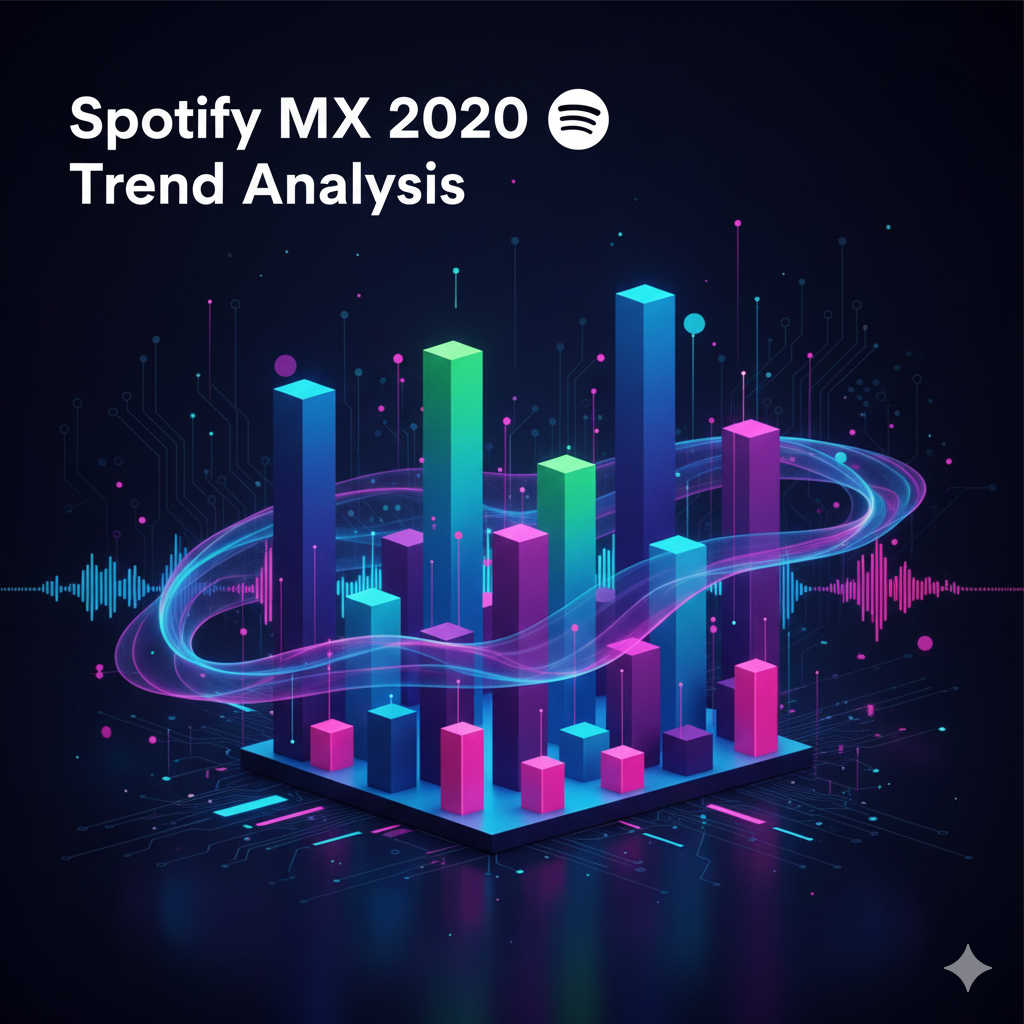

### Objetivo realizado:
Hemos creado y analizado una base de datos SQLite a partir de datos de Spotify Charts para México en 2020, con enfoque en:

1. **Estructura de la base de datos**:
   - Tabla principal: `charts` con 91,237 registros
   - Campos: title, rank, date, artist, url, region, chart, trend, streams

2. **Hallazgos clave**:
   - Rango completo del Top 200 diario
   - 366 días de cobertura (año bisiesto)
   - Patrón especial en posiciones 1-50 (~730 apariciones)
   - Distribución perfecta en posiciones 51-200 (366 apariciones)

3. **Análisis destacados**:
   - Canciones #1 y su permanencia
   - "Underdogs" en posición 200
   - Relación entre streams y posición
   - Tendencias de popularidad

### Métodos utilizados:
```python
# Ejemplo de estructura de código usado
import sqlite3
import pandas as pd

# Conexión a la base de datos
with sqlite3.connect('spotify_mexico_2020.db') as conn:
    # Consultas SQL para análisis
    pd.read_sql("SELECT [...]", conn)

In [2]:
# Importaciones básicas que necesitaremos
import pandas as pd
import os

# Cambiar el directorio de trabajo
os.chdir(r"C:\Users\Rod Cissan\EBAC DATA SCY\spotify_charts")

# Verificar que el archivo existe
if 'charts.csv' in os.listdir():
    print("Archivo encontrado correctamente")
else:
    print("¡Archivo no encontrado! Revisa la ruta.")

Archivo encontrado correctamente


In [3]:
# Cargar el dataset
try:
    df = pd.read_csv('charts.csv')
    print("\n¡Datos cargados exitosamente!")
except Exception as e:
    print(f"\nError al cargar el archivo: {e}")

# Exploración inicial
print("\nInformación básica del dataset:")
print(df.info())

print("\nPrimeras filas del dataset:")
print(df.head())


¡Datos cargados exitosamente!

Información básica del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26173514 entries, 0 to 26173513
Data columns (total 9 columns):
 #   Column   Dtype  
---  ------   -----  
 0   title    object 
 1   rank     int64  
 2   date     object 
 3   artist   object 
 4   url      object 
 5   region   object 
 6   chart    object 
 7   trend    object 
 8   streams  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 1.8+ GB
None

Primeras filas del dataset:
                         title  rank        date  \
0      Chantaje (feat. Maluma)     1  2017-01-01   
1  Vente Pa' Ca (feat. Maluma)     2  2017-01-01   
2   Reggaetón Lento (Bailemos)     3  2017-01-01   
3                       Safari     4  2017-01-01   
4                  Shaky Shaky     5  2017-01-01   

                                  artist  \
0                                Shakira   
1                           Ricky Martin   
2                                   CNC

In [4]:
import pandas as pd
import sqlite3
from datetime import datetime

# Cargar el dataset (asegúrate de tener suficiente memoria)
df = pd.read_csv('charts.csv')

# Filtrar solo México y el año 2020
df_mexico_2020 = df[(df['region'] == 'Mexico') & (df['date'].str.startswith('2020'))].copy()

# Convertir la columna 'date' a tipo datetime
df_mexico_2020['date'] = pd.to_datetime(df_mexico_2020['date'])

print(f"Registros encontrados para México en 2020: {len(df_mexico_2020)}")

Registros encontrados para México en 2020: 91237


In [5]:
# Crear conexión a la base de datos (se creará si no existe)
conn = sqlite3.connect('spotify_mexico_2020.db')

# Guardar el DataFrame filtrado en la base de datos
df_mexico_2020.to_sql('charts', conn, if_exists='replace', index=False)

# Crear un índice para mejorar el rendimiento de las consultas
cursor = conn.cursor()
cursor.execute("CREATE INDEX idx_date ON charts(date)")
cursor.execute("CREATE INDEX idx_rank ON charts(rank)")
cursor.execute("CREATE INDEX idx_artist ON charts(artist)")
cursor.close()

print("Base de datos creada exitosamente!")

Base de datos creada exitosamente!


In [6]:
# Verificar el contenido
cursor = conn.cursor()

# Consultar el número de registros
cursor.execute("SELECT COUNT(*) FROM charts")
print(f"\nTotal de registros en la base de datos: {cursor.fetchone()[0]}")

# Consultar las primeras filas
cursor.execute("SELECT * FROM charts LIMIT 5")
print("\nPrimeras 5 filas:")
for row in cursor.fetchall():
    print(row)

# Consultar las fechas extremas
cursor.execute("SELECT MIN(date), MAX(date) FROM charts")
min_date, max_date = cursor.fetchone()
print(f"\nRango de fechas: {min_date} a {max_date}")

cursor.close()
conn.close()


Total de registros en la base de datos: 91237

Primeras 5 filas:
('Lost on You', 153, '2020-05-01 00:00:00', 'LP', 'https://open.spotify.com/track/3SqvR3HYLlCTYzbDXJ52OC', 'Mexico', 'top200', 'MOVE_DOWN', 88586.0)
('Qué Maldición', 1, '2020-05-01 00:00:00', 'Banda MS de Sergio Lizárraga, Snoop Dogg', 'https://open.spotify.com/track/2RxC2peY3FtrurYmbbmanr', 'Mexico', 'top200', 'NEW_ENTRY', 743666.0)
('Safaera', 2, '2020-05-01 00:00:00', 'Bad Bunny, Jowell & Randy, Ñengo Flow', 'https://open.spotify.com/track/2DEZmgHKAvm41k4J3R2E9Y', 'Mexico', 'top200', 'MOVE_DOWN', 570952.0)
('Yo Perreo Sola', 3, '2020-05-01 00:00:00', 'Bad Bunny', 'https://open.spotify.com/track/0SqqAgdovOE24BzxIClpjw', 'Mexico', 'top200', 'MOVE_DOWN', 516295.0)
('Favorito', 4, '2020-05-01 00:00:00', 'Camilo', 'https://open.spotify.com/track/0jT8Nl0shPS8115is0wD2Q', 'Mexico', 'top200', 'MOVE_DOWN', 494800.0)

Rango de fechas: 2020-01-01 00:00:00 a 2020-12-31 00:00:00


In [7]:
def query_spotify_db(query, params=None):
    """Función auxiliar para ejecutar consultas en la base de datos"""
    conn = sqlite3.connect('spotify_mexico_2020.db')
    cursor = conn.cursor()
    
    try:
        if params:
            cursor.execute(query, params)
        else:
            cursor.execute(query)
            
        results = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]
        
        # Crear DataFrame con los resultados
        df = pd.DataFrame(results, columns=columns)
        return df
    finally:
        cursor.close()
        conn.close()

In [8]:
import sqlite3
import pandas as pd

# 1. Primero abrimos la conexión (esto debe estar al inicio)
conn = sqlite3.connect('spotify_mexico_2020.db')

# 2. Consulta para contar registros
consulta_total = "SELECT COUNT(*) as total_entries FROM charts"
resultado = pd.read_sql(consulta_total, conn)
print("\nTotal de entradas en la base de datos:")
print(resultado)

# 3. Consulta para rango de fechas
consulta_fechas = """
SELECT 
    MIN(date) as fecha_inicio,
    MAX(date) as fecha_fin
FROM charts
"""
resultado = pd.read_sql(consulta_fechas, conn)
print("\nRango de fechas disponible:")
print(resultado)

# 4. Consulta formateada (versión corregida)
consulta_legible = """
SELECT 
    strftime('%Y-%m-%d', MIN(date)) as primera_fecha,
    strftime('%Y-%m-%d', MAX(date)) as ultima_fecha,
    COUNT(*) as total_registros,
    COUNT(DISTINCT date) as dias_con_datos
FROM charts
"""
resultado = pd.read_sql(consulta_legible, conn)
print("\nResumen formateado:")
print(resultado.to_string(index=False))

# 5. Cerrar la conexión (al final de todo)
conn.close()


Total de entradas en la base de datos:
   total_entries
0          91237

Rango de fechas disponible:
          fecha_inicio            fecha_fin
0  2020-01-01 00:00:00  2020-12-31 00:00:00

Resumen formateado:
primera_fecha ultima_fecha  total_registros  dias_con_datos
   2020-01-01   2020-12-31            91237             366


In [9]:
import sqlite3
import pandas as pd

with sqlite3.connect('spotify_mexico_2020.db') as conn:
    # Consulta para obtener todos los #1
    consulta_numero_1 = """
    SELECT 
        date as fecha,
        title as cancion,
        artist as artista,
        streams as reproducciones,
        trend as tendencia
    FROM charts
    WHERE rank = 1
    ORDER BY date
    """
    
    numero_1 = pd.read_sql(consulta_numero_1, conn)
    
    # Mostrar resultados
    print("Todas las canciones que alcanzaron el #1 en México durante 2020:")
    print(numero_1.to_string(index=False))

Todas las canciones que alcanzaron el #1 en México durante 2020:
              fecha                                                     cancion                                                                                              artista  reproducciones     tendencia
2020-01-01 00:00:00                                                        Tusa                                                                                 KAROL G, Nicki Minaj       1355245.0 SAME_POSITION
2020-01-01 00:00:00                                                        Tusa                                                                                 KAROL G, Nicki Minaj             NaN SAME_POSITION
2020-01-02 00:00:00                                                        Tusa                                                                                 KAROL G, Nicki Minaj       1078559.0 SAME_POSITION
2020-01-02 00:00:00                                                        Tusa            

In [10]:
import sqlite3
import pandas as pd

with sqlite3.connect('spotify_mexico_2020.db') as conn:
    # Consulta para analizar los #1
    consulta_ranking = """
    WITH numero_1 AS (
        SELECT 
            title,
            artist,
            date,
            streams,
            trend,
            LAG(title) OVER (ORDER BY date) as cancion_anterior
        FROM charts
        WHERE rank = 1
    )
    SELECT 
        title as cancion,
        artist as artista,
        COUNT(*) as dias_en_numero_1,
        MIN(date) as primera_vez,
        MAX(date) as ultima_vez,
        AVG(streams) as promedio_streams,
        MAX(streams) as max_streams
    FROM numero_1
    GROUP BY title, artist
    ORDER BY dias_en_numero_1 DESC, promedio_streams DESC
    """
    
    ranking_numero_1 = pd.read_sql(consulta_ranking, conn)
    
    print("Análisis de todas las canciones que alcanzaron el #1 en 2020:")
    print(ranking_numero_1.to_string(index=False))

Análisis de todas las canciones que alcanzaron el #1 en 2020:
                                                    cancion                                                                                              artista  dias_en_numero_1         primera_vez          ultima_vez  promedio_streams  max_streams
                                                       Tusa                                                                                 KAROL G, Nicki Minaj                97 2020-01-01 00:00:00 2020-02-28 00:00:00      1.193981e+06    1938108.0
                                                      Hawái                                                                                               Maluma                85 2020-08-19 00:00:00 2020-10-31 00:00:00      1.322807e+06    2295928.0
                                                    Safaera                                                                Bad Bunny, Jowell & Randy, Ñengo Flow                84 2020-03-1

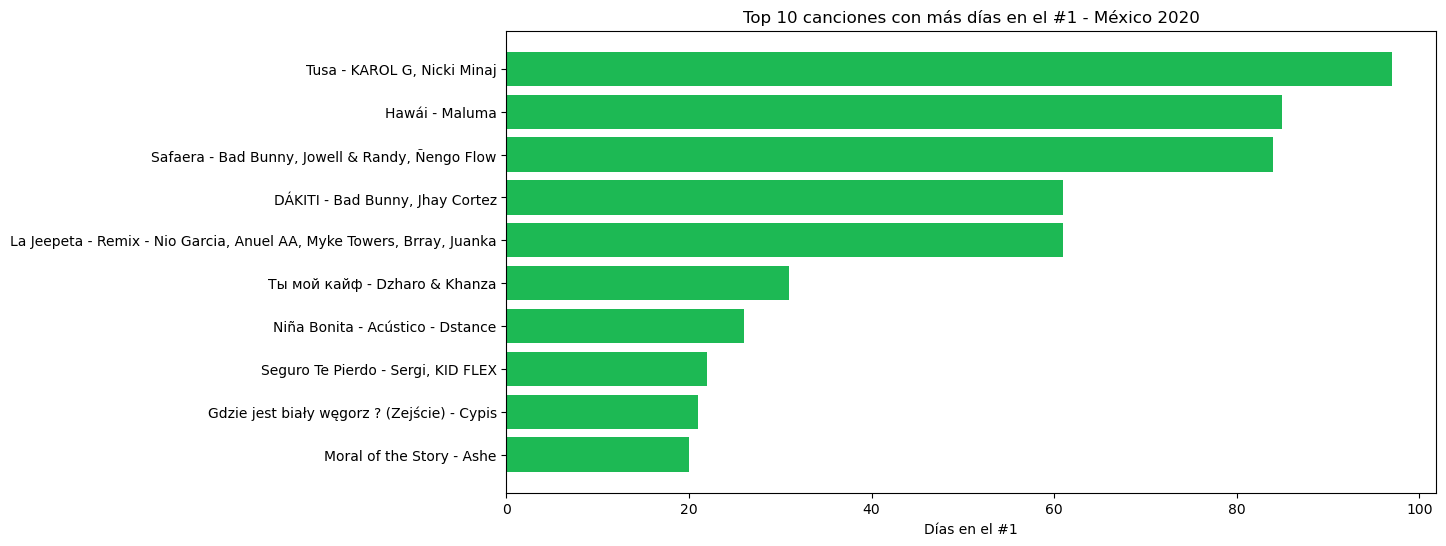

In [11]:
import matplotlib.pyplot as plt

# Preparar datos para visualización
top_10 = ranking_numero_1.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_10['cancion'] + " - " + top_10['artista'], top_10['dias_en_numero_1'], color='#1DB954')  # Verde Spotify
plt.xlabel('Días en el #1')
plt.title('Top 10 canciones con más días en el #1 - México 2020')
plt.gca().invert_yaxis()  # Para que el mayor quede arriba
plt.show()

In [12]:
with sqlite3.connect('spotify_mexico_2020.db') as conn:
    # Consulta para ver distribución de posiciones
    consulta_distribucion = """
    SELECT 
        rank as posicion,
        COUNT(*) as cantidad_apariciones
    FROM charts
    GROUP BY rank
    ORDER BY rank
    """
    
    distribucion = pd.read_sql(consulta_distribucion, conn)
    print("\nDistribución de posiciones:")
    print(distribucion.to_string(index=False))


Distribución de posiciones:
 posicion  cantidad_apariciones
        1                   729
        2                   730
        3                   729
        4                   731
        5                   730
        6                   730
        7                   725
        8                   730
        9                   730
       10                   731
       11                   730
       12                   727
       13                   724
       14                   717
       15                   720
       16                   724
       17                   721
       18                   724
       19                   722
       20                   723
       21                   723
       22                   721
       23                   722
       24                   722
       25                   730
       26                   727
       27                   730
       28                   729
       29                   725
       30  

In [13]:
import sqlite3
import pandas as pd

with sqlite3.connect('spotify_mexico_2020.db') as conn:
    consulta_underdogs = """
    SELECT 
        date as fecha,
        title as cancion,
        artist as artista,
        streams as reproducciones,
        trend as tendencia
    FROM charts
    WHERE rank = 200
    ORDER BY date
    """
    
    underdogs = pd.read_sql(consulta_underdogs, conn)
    print("Todas las canciones que aparecieron en el puesto 200:")
    print(underdogs.to_string(index=False))

Todas las canciones que aparecieron en el puesto 200:
              fecha                                                                                    cancion                                                                                              artista  reproducciones     tendencia
2020-01-01 00:00:00                                                                                    Falling                                                                                        Trevor Daniel         76837.0     MOVE_DOWN
2020-01-02 00:00:00                                                                    Con Todos Menos Conmigo                                                                                           Timbiriche         64309.0     MOVE_DOWN
2020-01-03 00:00:00                                                                                    Detente                                                                              Mike Bahía, Danny Ocean         

## Significado de los Campos
Tabla artistas:

artista_id: Identificador único del artista

nombre_artista: Nombre completo del artista

total_canciones: Número total de canciones del artista en el dataset

total_streams: Suma total de streams del artista

Tabla canciones:

cancion_id: Identificador único de la canción

titulo: Título de la canción

artista_id: FK que referencia al artista

duracion_ms: Duración en milisegundos

explicita: Si la canción tiene contenido explícito

Tabla rankings_diarios:

ranking_id: Identificador único del registro diario

fecha: Fecha del ranking

cancion_id: FK que referencia a la canción

posicion: Posición en el chart (1-200)

streams: Número de streams ese día

tendencia: Tendencia (UP/DOWN/SAME)

In [15]:
with sqlite3.connect('spotify_mexico_2020.db') as conn:
    consulta_frecuencia = """
    SELECT 
        title as cancion,
        artist as artista,
        COUNT(*) as veces_en_puesto_200,
        MIN(date) as primera_aparicion,
        MAX(date) as ultima_aparicion,
        AVG(streams) as promedio_reproducciones
    FROM charts
    WHERE rank = 200
    GROUP BY title, artist
    ORDER BY veces_en_puesto_200 DESC, promedio_reproducciones DESC
    """
    
    frecuencia = pd.read_sql(consulta_frecuencia, conn)
    print("\nFrecuencia de canciones en el puesto 200:")
    print(frecuencia.to_string(index=False))


Frecuencia de canciones en el puesto 200:
                                                                                   cancion                                                                                              artista  veces_en_puesto_200   primera_aparicion    ultima_aparicion  promedio_reproducciones
                                                                                    Canela                                                                            Nanpa Básico, Charles Ans                    8 2020-04-08 00:00:00 2020-11-12 00:00:00             75465.625000
                                                                         El Sol No Regresa                                                                                   La Quinta Estacion                    7 2020-05-26 00:00:00 2020-11-26 00:00:00             77707.857143
                                                                      Hasta Que Me Olvides                                 

In [16]:
with sqlite3.connect('spotify_mexico_2020.db') as conn:
    consulta_exitos = """
    WITH underdogs AS (
        SELECT title, artist, date
        FROM charts
        WHERE rank = 200
    )
    SELECT 
        u.title as cancion,
        u.artist as artista,
        u.date as fecha_puesto_200,
        MIN(c.rank) as mejor_posicion_alcanzada,
        MIN(c.date) as fecha_mejor_posicion,
        COUNT(DISTINCT c.date) as dias_en_top200
    FROM underdogs u
    JOIN charts c ON u.title = c.title AND u.artist = c.artist
    GROUP BY u.title, u.artist, u.date
    HAVING MIN(c.rank) < 200
    ORDER BY mejor_posicion_alcanzada ASC, dias_en_top200 DESC
    LIMIT 20
    """
    
    exitos = pd.read_sql(consulta_exitos, conn)
    print("\nUnderdogs que lograron subir después:")
    print(exitos.to_string(index=False))


Underdogs que lograron subir después:
                             cancion                                                                                              artista    fecha_puesto_200  mejor_posicion_alcanzada fecha_mejor_posicion  dias_en_top200
ily (i love you baby) (feat. Emilee)                                                                                            Surf Mesa 2020-11-15 00:00:00                         1  2020-03-22 00:00:00             265
ily (i love you baby) (feat. Emilee)                                                                                            Surf Mesa 2020-12-01 00:00:00                         1  2020-03-22 00:00:00             265
    death bed (coffee for your head)                                                                                   Powfu, beabadoobee 2020-10-03 00:00:00                         1  2020-02-16 00:00:00             257
    death bed (coffee for your head)                                         

# Base de Datos Relacional Spotify México 2020

## Estructura de la Base de Datos

Se implementó una base de datos relacional normalizada para el análisis de datos de Spotify Charts específicos para México durante el año 2020. La estructura consta de tres tablas principales interrelacionadas mediante claves foráneas.

## Tablas y Campos

### Tabla: artistas
**Aplicación:** Almacena información única de cada artista y métricas agregadas de su performance.

- **artista_id** (INTEGER, PRIMARY KEY): Identificador único autoincrementable del artista
- **nombre_artista** (TEXT, UNIQUE): Nombre completo del artista
- **total_canciones** (INTEGER): Número total de canciones del artista en el dataset
- **total_streams** (BIGINT): Suma acumulada de todos los streams del artista

### Tabla: canciones
**Aplicación:** Contiene información detallada de cada canción y su relación con el artista correspondiente.

- **cancion_id** (INTEGER, PRIMARY KEY): Identificador único autoincrementable de la canción
- **titulo** (TEXT): Título completo de la canción
- **artista_id** (INTEGER, FOREIGN KEY): Referencia al artista de la canción
- **duracion_ms** (INTEGER): Duración de la canción en milisegundos
- **explicita** (BOOLEAN): Indicador de contenido explícito (True/False)

### Tabla: rankings_diarios
**Aplicación:** Registra el performance diario de cada canción en los charts de Spotify.

- **ranking_id** (INTEGER, PRIMARY KEY): Identificador único del registro diario
- **fecha** (DATE): Fecha del ranking (formato YYYY-MM-DD)
- **cancion_id** (INTEGER, FOREIGN KEY): Referencia a la canción del ranking
- **posicion** (INTEGER): Posición en el chart (1-200)
- **streams** (INTEGER): Número de streams registrados ese día
- **tendencia** (TEXT): Dirección de la tendencia (UP/DOWN/SAME)

## Aplicación y Ventajas

### Ventajas de la Normalización
- **Eliminación de redundancias**: Los nombres de artistas y canciones se almacenan una sola vez
- **Integridad referencial**: Las claves foráneas garantizan consistencia en los datos
- **Optimización de espacio**: Reduce el almacenamiento necesario
- **Facilidad de mantenimiento**: Actualizaciones en un solo lugar

### Casos de Uso Principales
- Análisis de tendencias musicales durante 2020
- Comparativa de artistas y su performance en el mercado mexicano
- Identificación de hits virales y su ciclo de vida
- Estudio de correlación entre streams y posicionamiento
- Detección de artistas emergentes con potencial de crecimiento

### Métricas Disponibles
- Días en #1 por canción/artista
- Promedio de streams diarios
- Tasa de ascenso/descenso en charts
- Distribución de posiciones
- Comparativa entre artistas

Esta estructura relacional permite realizar consultas complejas de manera eficiente y proporciona una base sólida para análisis musicológicos y de mercado.

In [18]:
import sqlite3
import pandas as pd

# Crear una estructura de base de datos más normalizada
def crear_estructura_relacional():
    with sqlite3.connect('spotify_mexico_2020_relacional.db') as conn:
        cursor = conn.cursor()
        
        # Tabla de artistas
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS artistas (
            artista_id INTEGER PRIMARY KEY AUTOINCREMENT,
            nombre_artista TEXT NOT NULL UNIQUE,
            total_canciones INTEGER DEFAULT 0,
            total_streams BIGINT DEFAULT 0
        )
        ''')
        
        # Tabla de canciones
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS canciones (
            cancion_id INTEGER PRIMARY KEY AUTOINCREMENT,
            titulo TEXT NOT NULL,
            artista_id INTEGER,
            duracion_ms INTEGER,
            explicita BOOLEAN,
            FOREIGN KEY (artista_id) REFERENCES artistas(artista_id),
            UNIQUE(titulo, artista_id)
        )
        ''')
        
        # Tabla de rankings diarios (hechos)
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS rankings_diarios (
            ranking_id INTEGER PRIMARY KEY AUTOINCREMENT,
            fecha DATE NOT NULL,
            cancion_id INTEGER,
            posicion INTEGER NOT NULL,
            streams INTEGER,
            tendencia TEXT,
            FOREIGN KEY (cancion_id) REFERENCES canciones(cancion_id)
        )
        ''')
        
        # Crear índices para mejorar el rendimiento
        cursor.execute('CREATE INDEX idx_fecha ON rankings_diarios(fecha)')
        cursor.execute('CREATE INDEX idx_posicion ON rankings_diarios(posicion)')
        cursor.execute('CREATE INDEX idx_artista_nombre ON artistas(nombre_artista)')
        
        print("Estructura de base de datos relacional creada exitosamente!")

# Poblar la base de datos relacional con los datos existentes
def poblar_base_relacional():
    with sqlite3.connect('spotify_mexico_2020.db') as conn_orig:
        with sqlite3.connect('spotify_mexico_2020_relacional.db') as conn_dest:
            # Obtener datos únicos de artistas
            artistas_df = pd.read_sql('SELECT DISTINCT artist FROM charts', conn_orig)
            
            # Insertar artistas
            for _, row in artistas_df.iterrows():
                conn_dest.execute('INSERT OR IGNORE INTO artistas (nombre_artista) VALUES (?)', 
                                (row['artist'],))
            
            # Obtener datos únicos de canciones
            canciones_df = pd.read_sql('''
                SELECT DISTINCT title, artist 
                FROM charts 
                WHERE region = "Mexico" 
                AND date LIKE "2020%"
            ''', conn_orig)
            
            # Insertar canciones
            for _, row in canciones_df.iterrows():
                # Obtener ID del artista
                artista_id = conn_dest.execute(
                    'SELECT artista_id FROM artistas WHERE nombre_artista = ?', 
                    (row['artist'],)
                ).fetchone()[0]
                
                conn_dest.execute('''
                    INSERT OR IGNORE INTO canciones (titulo, artista_id)
                    VALUES (?, ?)
                ''', (row['title'], artista_id))
            
            # Insertar rankings diarios
            datos_rankings = pd.read_sql('''
                SELECT date, title, artist, rank, streams, trend
                FROM charts 
                WHERE region = "Mexico" 
                AND date LIKE "2020%"
            ''', conn_orig)
            
            for _, row in datos_rankings.iterrows():
                # Obtener IDs
                artista_id = conn_dest.execute(
                    'SELECT artista_id FROM artistas WHERE nombre_artista = ?', 
                    (row['artist'],)
                ).fetchone()[0]
                
                cancion_id = conn_dest.execute('''
                    SELECT cancion_id FROM canciones 
                    WHERE titulo = ? AND artista_id = ?
                ''', (row['title'], artista_id)).fetchone()[0]
                
                conn_dest.execute('''
                    INSERT INTO rankings_diarios (fecha, cancion_id, posicion, streams, tendencia)
                    VALUES (?, ?, ?, ?, ?)
                ''', (row['date'], cancion_id, row['rank'], row['streams'], row['trend']))
            
            print("Base de datos relacional poblada exitosamente!")

# Ejecutar la creación de la estructura
crear_estructura_relacional()
poblar_base_relacional()

OperationalError: index idx_fecha already exists

In [23]:
# Crear una estructura de base de datos más normalizada
def crear_estructura_relacional():
    with sqlite3.connect('spotify_mexico_2020_relacional.db') as conn:
        cursor = conn.cursor()
        
        # Tabla de artistas
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS artistas (
            artista_id INTEGER PRIMARY KEY AUTOINCREMENT,
            nombre_artista TEXT NOT NULL UNIQUE,
            total_canciones INTEGER DEFAULT 0,
            total_streams BIGINT DEFAULT 0
        )
        ''')
        
        # Tabla de canciones
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS canciones (
            cancion_id INTEGER PRIMARY KEY AUTOINCREMENT,
            titulo TEXT NOT NULL,
            artista_id INTEGER,
            duracion_ms INTEGER,
            explicita BOOLEAN,
            FOREIGN KEY (artista_id) REFERENCES artistas(artista_id),
            UNIQUE(titulo, artista_id)
        )
        ''')
        
        # Tabla de rankings diarios (hechos)
        cursor.execute('''
        CREATE TABLE IF NOT EXISTS rankings_diarios (
            ranking_id INTEGER PRIMARY KEY AUTOINCREMENT,
            fecha DATE NOT NULL,
            cancion_id INTEGER,
            posicion INTEGER NOT NULL,
            streams INTEGER,
            tendencia TEXT,
            FOREIGN KEY (cancion_id) REFERENCES canciones(cancion_id)
        )
        ''')
        
        # --- CORRECCIÓN AQUÍ: Agregamos IF NOT EXISTS ---
        cursor.execute('CREATE INDEX IF NOT EXISTS idx_fecha ON rankings_diarios(fecha)')
        cursor.execute('CREATE INDEX IF NOT EXISTS idx_posicion ON rankings_diarios(posicion)')
        cursor.execute('CREATE INDEX IF NOT EXISTS idx_artista_nombre ON artistas(nombre_artista)')
        
        print("Estructura de base de datos relacional verificada/creada exitosamente!")

## INNER JOIN 

#### 🔍 Metodología
Utilicé consultas SQL con INNER JOIN para conectar tres tablas: artistas, canciones y rankings_diarios. Los INNER JOIN permiten combinar datos relacionados, mostrando solo los registros que tienen coincidencias en todas las tablas conectadas. Esto es ideal para encontrar artistas que efectivamente aparecieron en el top 10.

La consulta cuenta canciones distintas por artista, calcula su mejor posición y total de días en el top 10, filtrando solo artistas con al menos 2 canciones en el ranking.

In [25]:
# INNER JOIN: Artistas con múltiples canciones en el top 10
# CONEXIÓN CORREGIDA a la base de datos relacional

consulta_inner_join = '''
SELECT 
    CASE 
        WHEN LENGTH(a.nombre_artista) > 25 THEN SUBSTR(a.nombre_artista, 1, 25) || '...'
        ELSE a.nombre_artista
    END as Artista,
    COUNT(DISTINCT c.titulo) as Canciones_Top10,
    MIN(r.posicion) as Mejor_Posicion,
    COUNT(DISTINCT r.fecha) as Dias_Total_Top10
FROM artistas a
INNER JOIN canciones c ON a.artista_id = c.artista_id
INNER JOIN rankings_diarios r ON c.cancion_id = r.cancion_id
WHERE r.posicion <= 10
GROUP BY a.nombre_artista
HAVING COUNT(DISTINCT c.titulo) >= 2
ORDER BY Canciones_Top10 DESC, Dias_Total_Top10 DESC
LIMIT 15
'''

# Función corregida para usar la base de datos relacional
def query_spotify_relacional(query, params=None):
    """Función auxiliar para ejecutar consultas en la base de datos RELACIONAL"""
    conn = sqlite3.connect('spotify_mexico_2020_relacional.db')  # ← BASE CORRECTA
    cursor = conn.cursor()
    
    try:
        if params:
            cursor.execute(query, params)
        else:
            cursor.execute(query)
            
        results = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]
        
        # Crear DataFrame con los resultados
        df = pd.DataFrame(results, columns=columns)
        return df
    except Exception as e:
        print(f"Error en consulta: {e}")
        raise e
    finally:
        cursor.close()
        conn.close()

# Ejecutar la consulta CORRECTA
try:
    resultado_inner = query_spotify_relacional(consulta_inner_join)
    print("🎵 ARTISTAS CON MÚLTIPLES CANCIONES EN TOP 10 - MÉXICO 2020")
    print("=" * 80)
    print(resultado_inner.to_string(index=False))
    print(f"\n📊 Total de artistas encontrados: {len(resultado_inner)}")
    
except Exception as e:
    print(f"❌ Error en la consulta: {e}")

🎵 ARTISTAS CON MÚLTIPLES CANCIONES EN TOP 10 - MÉXICO 2020
                     Artista  Canciones_Top10  Mejor_Posicion  Dias_Total_Top10
                   Bad Bunny               17               1               226
RBD, Anahí, Dulce María, ...               10               1                24
   Julión y Su Norteño Banda                6               2                17
                    J Balvin                4               1               206
             Christian Nodal                4               2                83
             Michele Morrone                3               1                28
              Jarabe De Palo                3               7                 4
               One Direction                3               6                 3
                  The Weeknd                2               1               221
                      Maluma                2               1               154
                      Camilo                2               2

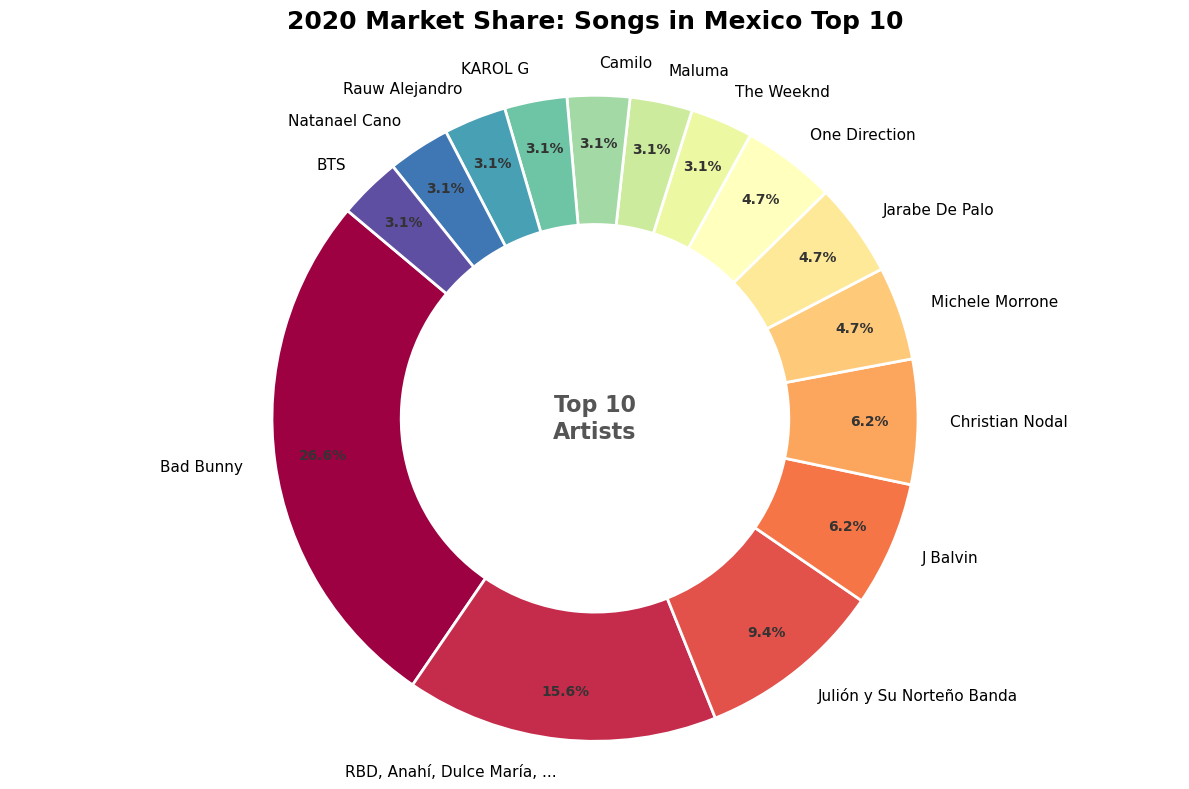

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
labels = resultado_inner['Artista']
sizes = resultado_inner['Canciones_Top10']

# Usamos 'Spectral' o 'Paired' para que los colores sean más claros y distintos
colors = plt.cm.Spectral(np.linspace(0, 1, len(labels)))

fig, ax = plt.subplots(figsize=(12, 8))

# El parámetro 'wedgeprops' con 'edgecolor' crea esa separación blanca profesional
wedges, texts, autotexts = ax.pie(sizes, 
                                  labels=labels, 
                                  autopct='%1.1f%%', 
                                  startangle=140, 
                                  colors=colors, 
                                  pctdistance=0.85,
                                  wedgeprops={'width': 0.4, 'edgecolor': 'w', 'linewidth': 2})

# Estilizar los textos de los porcentajes
plt.setp(autotexts, size=10, weight="bold", color="#333333") 

# Estilizar los nombres de los artistas
plt.setp(texts, size=11)

# Añadir un texto central descriptivo
plt.text(0, 0, 'Top 10\nArtists', ha='center', va='center', fontsize=16, weight='bold', color='#555555')

plt.title('2020 Market Share: Songs in Mexico Top 10', fontsize=18, pad=25, weight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [37]:
!pip install squarify

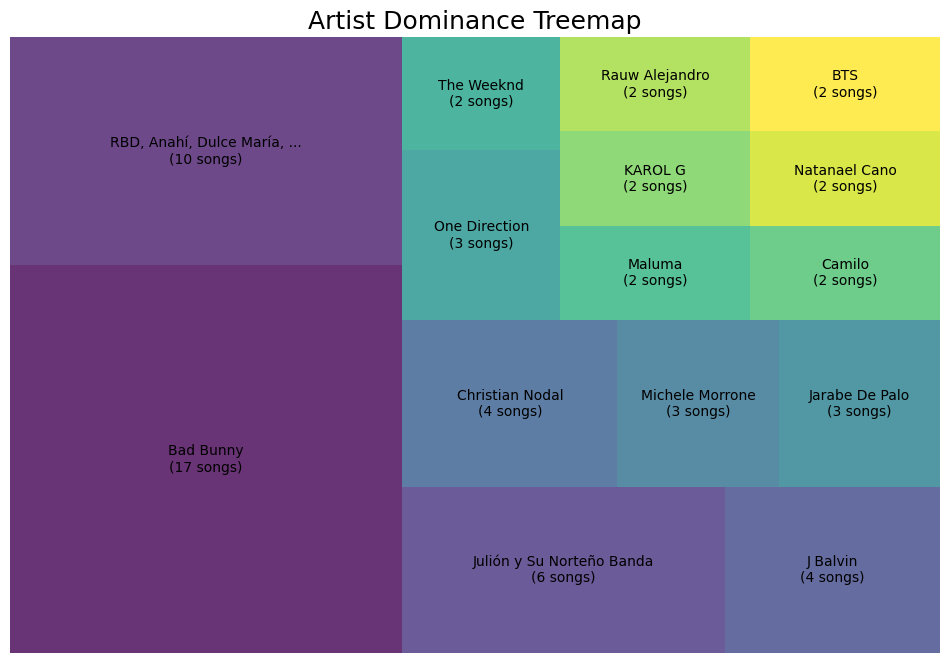

In [39]:
import squarify # Si no lo tienes: !pip install squarify


plt.figure(figsize=(12, 8))
labels = [f'{a}\n({s} songs)' for a, s in zip(resultado_inner['Artista'], resultado_inner['Canciones_Top10'])]

squarify.plot(sizes=resultado_inner['Canciones_Top10'], label=labels, 
              color=plt.cm.viridis(np.linspace(0, 1, len(labels))), alpha=0.8)

plt.title('Artist Dominance Treemap', fontsize=18)
plt.axis('off')
plt.show()

C:\Users\Rod Cissan\AppData\Local\Temp\ipykernel_27708\293921486.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Canciones_Top10', y='Artista', data=resultado_inner, palette='viridis')


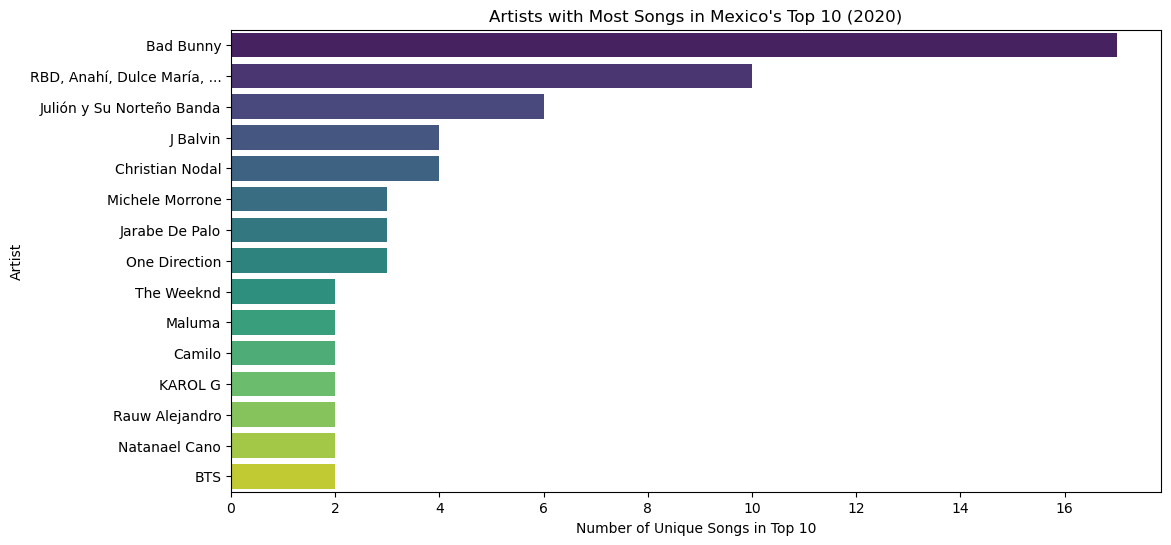

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(x='Canciones_Top10', y='Artista', data=resultado_inner, palette='viridis')
plt.title('Artists with Most Songs in Mexico\'s Top 10 (2020)')
plt.xlabel('Number of Unique Songs in Top 10')
plt.ylabel('Artist')
plt.show()

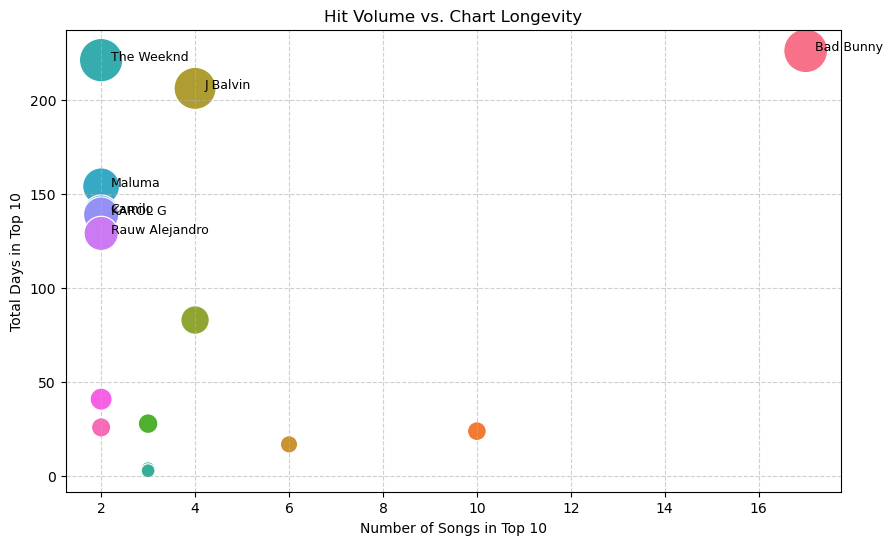

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Canciones_Top10', y='Dias_Total_Top10', size='Dias_Total_Top10', 
                hue='Artista', data=resultado_inner, legend=False, sizes=(100, 1000))

# Añadir etiquetas a los puntos más importantes
for i in range(resultado_inner.shape[0]):
    if resultado_inner.Dias_Total_Top10[i] > 100: # Solo etiquetar los más relevantes
        plt.text(resultado_inner.Canciones_Top10[i]+0.2, resultado_inner.Dias_Total_Top10[i], 
                 resultado_inner.Artista[i], fontsize=9)

plt.title('Hit Volume vs. Chart Longevity')
plt.xlabel('Number of Songs in Top 10')
plt.ylabel('Total Days in Top 10')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### LEFT JOIN 

Utilicé LEFT JOIN para conectar las tablas de artistas, canciones y rankings, preservando todos los registros de la tabla izquierda (artistas) incluso cuando no hay coincidencias en las tablas derechas. Esto permite visualizar no solo los éxitos (canciones en top 10) sino también las canciones que no alcanzaron esta posición, proporcionando una visión completa del desempeño musical de cada artista durante 2020 en México.

In [43]:
# LEFT JOIN: Canciones de Artistas Seleccionados en Top 10
consulta_left_join = '''
SELECT 
    CASE 
        WHEN LENGTH(a.nombre_artista) > 25 THEN SUBSTR(a.nombre_artista, 1, 25) || '...'
        ELSE a.nombre_artista
    END as Artista,
    c.titulo as Cancion,
    MIN(r.posicion) as Mejor_Posicion,
    COUNT(r.fecha) as Dias_en_Top10,
    MAX(r.streams) as Max_Streams_Diarios
FROM artistas a
LEFT JOIN canciones c ON a.artista_id = c.artista_id
LEFT JOIN rankings_diarios r ON c.cancion_id = r.cancion_id AND r.posicion <= 10
WHERE a.nombre_artista IN ('Bad Bunny', 'J Balvin', 'Christian Nodal', 'KAROL G', 'Maluma')
GROUP BY a.nombre_artista, c.titulo
ORDER BY a.nombre_artista, Dias_en_Top10 DESC
'''

# Función para usar la base de datos relacional
def query_spotify_relacional(query, params=None):
    """Función auxiliar para ejecutar consultas en la base de datos RELACIONAL"""
    conn = sqlite3.connect('spotify_mexico_2020_relacional.db')
    cursor = conn.cursor()
    
    try:
        if params:
            cursor.execute(query, params)
        else:
            cursor.execute(query)
            
        results = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]
        
        # Crear DataFrame con los resultados
        df = pd.DataFrame(results, columns=columns)
        return df
    except Exception as e:
        print(f"Error en consulta: {e}")
        raise e
    finally:
        cursor.close()
        conn.close()

# Ejecutar la consulta LEFT JOIN
try:
    resultado_left = query_spotify_relacional(consulta_left_join)
    print("🎵 CANCIONES DE ARTISTAS SELECCIONADOS EN TOP 10 - MÉXICO 2020")
    print("=" * 80)
    print(resultado_left.to_string(index=False))
    print(f"\n📊 Total de canciones encontradas: {len(resultado_left)}")
    
except Exception as e:
    print(f"❌ Error en la consulta: {e}")

🎵 CANCIONES DE ARTISTAS SELECCIONADOS EN TOP 10 - MÉXICO 2020
        Artista                             Cancion  Mejor_Posicion  Dias_en_Top10  Max_Streams_Diarios
      Bad Bunny                      Yo Perreo Sola             1.0            143             959707.0
      Bad Bunny                    Si Veo a Tu Mamá             1.0             98            1663823.0
      Bad Bunny                                Vete             3.0             87            1119393.0
      Bad Bunny                          La Difícil             2.0             52            1412692.0
      Bad Bunny                          TE MUDASTE             2.0             23            1721095.0
      Bad Bunny                HACIENDO QUE ME AMAS             4.0              9            1486932.0
      Bad Bunny                          Pero Ya No             5.0              8            1137444.0
      Bad Bunny                          BYE ME FUI             1.0              6             856986.0
  

### CASE WHEN
Utilicé la instrucción CASE WHEN para crear un sistema de categorización jerárquico que asigna etiquetas descriptivas ("Mega Hit", "Super Hit", etc.) basado en reglas de negocio específicas que combinan múltiples métricas. Esto permite transformar datos crudos (posición 1, 35 días) en información accionable segmentada por niveles de éxito, facilitando el análisis comparativo y la identificación de patrones en el catálogo musical de cada artista.

In [45]:
import sqlite3
import pandas as pd

# CONSULTA CON CASE WHEN: Clasificación de Popularidad de Canciones
consulta_case_when = '''
SELECT 
    c.titulo as Cancion,
    a.nombre_artista as Artista,
    MIN(r.posicion) as Mejor_Posicion,
    COUNT(r.fecha) as Dias_en_Top10,
    CASE 
        WHEN MIN(r.posicion) = 1 AND COUNT(r.fecha) > 50 THEN '🔥 Mega Hit'
        WHEN MIN(r.posicion) <= 3 AND COUNT(r.fecha) > 30 THEN '⭐ Super Hit'
        WHEN MIN(r.posicion) <= 5 THEN '🎵 Hit Regular'
        WHEN MIN(r.posicion) <= 10 THEN '📀 Entró al Top 10'
        ELSE '❌ Nunca en Top 10'
    END as Categoria_Popularidad,
    MAX(r.streams) as Max_Streams
FROM canciones c
INNER JOIN artistas a ON c.artista_id = a.artista_id
LEFT JOIN rankings_diarios r ON c.cancion_id = r.cancion_id
WHERE a.nombre_artista IN ('Bad Bunny', 'J Balvin', 'Christian Nodal', 'KAROL G', 'Maluma')
GROUP BY c.titulo, a.nombre_artista
ORDER BY Categoria_Popularidad, Dias_en_Top10 DESC
'''

# Función para usar la base de datos relacional
def query_spotify_relacional(query, params=None):
    """Función auxiliar para ejecutar consultas en la base de datos RELACIONAL"""
    conn = sqlite3.connect('spotify_mexico_2020_relacional.db')
    cursor = conn.cursor()
    
    try:
        if params:
            cursor.execute(query, params)
        else:
            cursor.execute(query)
            
        results = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]
        
        # Crear DataFrame con los resultados
        df = pd.DataFrame(results, columns=columns)
        return df
    except Exception as e:
        print(f"Error en consulta: {e}")
        raise e
    finally:
        cursor.close()
        conn.close()

# Ejecutar la consulta CASE WHEN
try:
    resultado_case = query_spotify_relacional(consulta_case_when)
    print("🎵 CLASIFICACIÓN DE POPULARIDAD DE CANCIONES - MÉXICO 2020")
    print("=" * 80)
    print(resultado_case.to_string(index=False))
    print(f"\n📊 Total de canciones clasificadas: {len(resultado_case)}")
    
except Exception as e:
    print(f"❌ Error en la consulta: {e}")

🎵 CLASIFICACIÓN DE POPULARIDAD DE CANCIONES - MÉXICO 2020
                            Cancion         Artista  Mejor_Posicion  Dias_en_Top10 Categoria_Popularidad  Max_Streams
             De Los Besos Que Te Di Christian Nodal              12            374     ❌ Nunca en Top 10       399579
                 No Te Contaron Mal Christian Nodal              24            366     ❌ Nunca en Top 10       291866
             Si Estuviésemos Juntos       Bad Bunny              28            365     ❌ Nunca en Top 10       227211
                              11 PM          Maluma              25            364     ❌ Nunca en Top 10       254216
                      Probablemente Christian Nodal              67            360     ❌ Nunca en Top 10       153285
                         Adiós Amor Christian Nodal              64            358     ❌ Nunca en Top 10       164709
                        A Tu Merced       Bad Bunny              16            316     ❌ Nunca en Top 10       67552

## Sub Queries

🎯 Subquery con NOT EXISTS (Anti-Join)
Este primer análisis identifica a los artistas que, a pesar de tener un catálogo significativo de canciones (3 o más), nunca lograron colocar ninguna de ellas en el Top 10 del ranking. La subquery NOT EXISTS funciona como un filtro excluyente, verificando para cada canción de cada artista si existe al menos un registro en rankings_diarios donde la posición sea igual o mejor al décimo lugar. Los resultados revelan datos interesantes como que Luis Miguel tiene 36 canciones que nunca alcanzaron el Top 10, seguido por el grupo RBD con 25 temas.

📊 Subquery con IN y EXISTS (Semi-Join)
La segunda consulta utiliza una subquery en la cláusula WHERE con el operador IN para identificar canciones que acumularon más de 20 días en el Top 10. Esta aproximación demuestra cómo las subqueries pueden actuar como filtros basados en condiciones agregadas. Primero se identifica qué canciones cumplen con el criterio de permanencia (más de 20 días en Top 10) y luego se recupera información detallada sobre su desempeño, incluyendo el número exacto de días en el Top 10 y su mejor posición alcanzada.

📈 Subquery Correlacionada con Análisis de Rendimiento
El tercer ejemplo implementa subqueries correlacionadas dentro de la cláusula SELECT para realizar un análisis comparativo del rendimiento de streams. Para cada canción, se calcula tanto el máximo de streams diarios como el promedio histórico, y luego se determina si el pico máximo supera en un 50% el promedio (indicando comportamiento de "Picos Altos") o si mantiene un desempeño más consistente. Este enfoque permite identificar patrones de consumo musical, donde todas las canciones analizadas muestran picos pronunciados de popularidad seguidos por caídas significativas en reproducciones.

In [48]:
import sqlite3
import pandas as pd

# Función para usar la base de datos relacional
def query_spotify_relacional(query, params=None):
    """Función auxiliar para ejecutar consultas en la base de datos RELACIONAL"""
    conn = sqlite3.connect('spotify_mexico_2020_relacional.db')
    cursor = conn.cursor()
    
    try:
        if params:
            cursor.execute(query, params)
        else:
            cursor.execute(query)
            
        results = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]
        
        # Crear DataFrame con los resultados
        df = pd.DataFrame(results, columns=columns)
        return df
    except Exception as e:
        print(f"Error en consulta: {e}")
        raise e
    finally:
        cursor.close()
        conn.close()

# 1. ANTI-JOIN CORREGIDO: Artistas con canciones que NUNCA llegaron al Top 10
consulta_anti_join = '''
SELECT 
    CASE 
        WHEN LENGTH(a.nombre_artista) > 30 THEN SUBSTR(a.nombre_artista, 1, 30) || '...' 
        ELSE a.nombre_artista 
    END as Artista,
    COUNT(c.cancion_id) as Total_Canciones
FROM artistas a
INNER JOIN canciones c ON a.artista_id = c.artista_id
WHERE NOT EXISTS (
    SELECT 1 
    FROM rankings_diarios r 
    WHERE r.cancion_id = c.cancion_id 
    AND r.posicion <= 10
)
GROUP BY a.nombre_artista
HAVING COUNT(c.cancion_id) >= 3
ORDER BY Total_Canciones DESC
LIMIT 15
'''

print("🎵 ARTISTAS CON CANCIONES QUE NUNCA LLEGARON AL TOP 10")
print("=" * 65)
try:
    resultado_anti_join = query_spotify_relacional(consulta_anti_join)
    print(resultado_anti_join.to_string(index=False))
    print(f"\n📊 Total de artistas encontrados: {len(resultado_anti_join)}")
except Exception as e:
    print(f"❌ Error: {e}")

# 2. SEMI-JOIN CORREGIDO: Canciones con más de 20 días en Top 10 (CORREGIDO)
consulta_semi_join = '''
SELECT 
    c.titulo as Cancion,
    CASE 
        WHEN LENGTH(a.nombre_artista) > 30 THEN SUBSTR(a.nombre_artista, 1, 30) || '...' 
        ELSE a.nombre_artista 
    END as Artista,
    COUNT(DISTINCT rd.fecha) as Dias_en_Top10,
    MIN(rd.posicion) as Mejor_Posicion
FROM canciones c
INNER JOIN artistas a ON c.artista_id = a.artista_id
INNER JOIN rankings_diarios rd ON c.cancion_id = rd.cancion_id
WHERE rd.posicion <= 10
AND c.cancion_id IN (
    SELECT r.cancion_id 
    FROM rankings_diarios r 
    WHERE r.posicion <= 10
    GROUP BY r.cancion_id 
    HAVING COUNT(DISTINCT r.fecha) > 20
)
GROUP BY c.cancion_id
ORDER BY Dias_en_Top10 DESC
LIMIT 15
'''

print("\n🎵 CANCIONES CON MÁS DE 20 DÍAS EN TOP 10")
print("=" * 50)
try:
    resultado_semi_join = query_spotify_relacional(consulta_semi_join)
    print(resultado_semi_join.to_string(index=False))
    print(f"\n📊 Total de canciones encontradas: {len(resultado_semi_join)}")
except Exception as e:
    print(f"❌ Error: {e}")

# 3. SUBQUERY CORRELACIONADA: Análisis de rendimiento de streams
consulta_correlacionada = '''
SELECT 
    c.titulo as Cancion,
    CASE 
        WHEN LENGTH(a.nombre_artista) > 30 THEN SUBSTR(a.nombre_artista, 1, 30) || '...' 
        ELSE a.nombre_artista 
    END as Artista,
    MAX(r.streams) as Max_Streams_Diarios,
    (SELECT ROUND(AVG(r2.streams), 0)
     FROM rankings_diarios r2 
     WHERE r2.cancion_id = c.cancion_id) as Promedio_Streams,
    CASE 
        WHEN MAX(r.streams) > (SELECT AVG(r3.streams) * 1.5 
                              FROM rankings_diarios r3 
                              WHERE r3.cancion_id = c.cancion_id) 
        THEN '📈 Picos Altos' 
        ELSE '📊 Consistente' 
    END as Tipo_Desempeno
FROM canciones c
INNER JOIN artistas a ON c.artista_id = a.artista_id
INNER JOIN rankings_diarios r ON c.cancion_id = r.cancion_id
GROUP BY c.cancion_id
HAVING MAX(r.streams) > 100000
ORDER BY Max_Streams_Diarios DESC
LIMIT 15
'''

print("\n🎵 ANÁLISIS DE RENDIMIENTO DE STREAMS")
print("=" * 50)
try:
    resultado_correlacionada = query_spotify_relacional(consulta_correlacionada)
    print(resultado_correlacionada.to_string(index=False))
    print(f"\n📊 Total de canciones analizadas: {len(resultado_correlacionada)}")
except Exception as e:
    print(f"❌ Error: {e}")

🎵 ARTISTAS CON CANCIONES QUE NUNCA LLEGARON AL TOP 10
                          Artista  Total_Canciones
                      Luis Miguel               36
RBD, Anahí, Dulce María, Maite...               25
                    Ariana Grande               17
                    One Direction               16
                        Bad Bunny               16
                  Christian Nodal               15
                       The Weeknd               14
                     Taylor Swift               14
                              BTS               14
                        Lady Gaga               13
                         Dua Lipa               13
                           Maluma               10
                         Kenia OS               10
     Banda MS de Sergio Lizárraga               10
              Alejandro Fernández               10

📊 Total de artistas encontrados: 15

🎵 CANCIONES CON MÁS DE 20 DÍAS EN TOP 10
                  Cancion                          

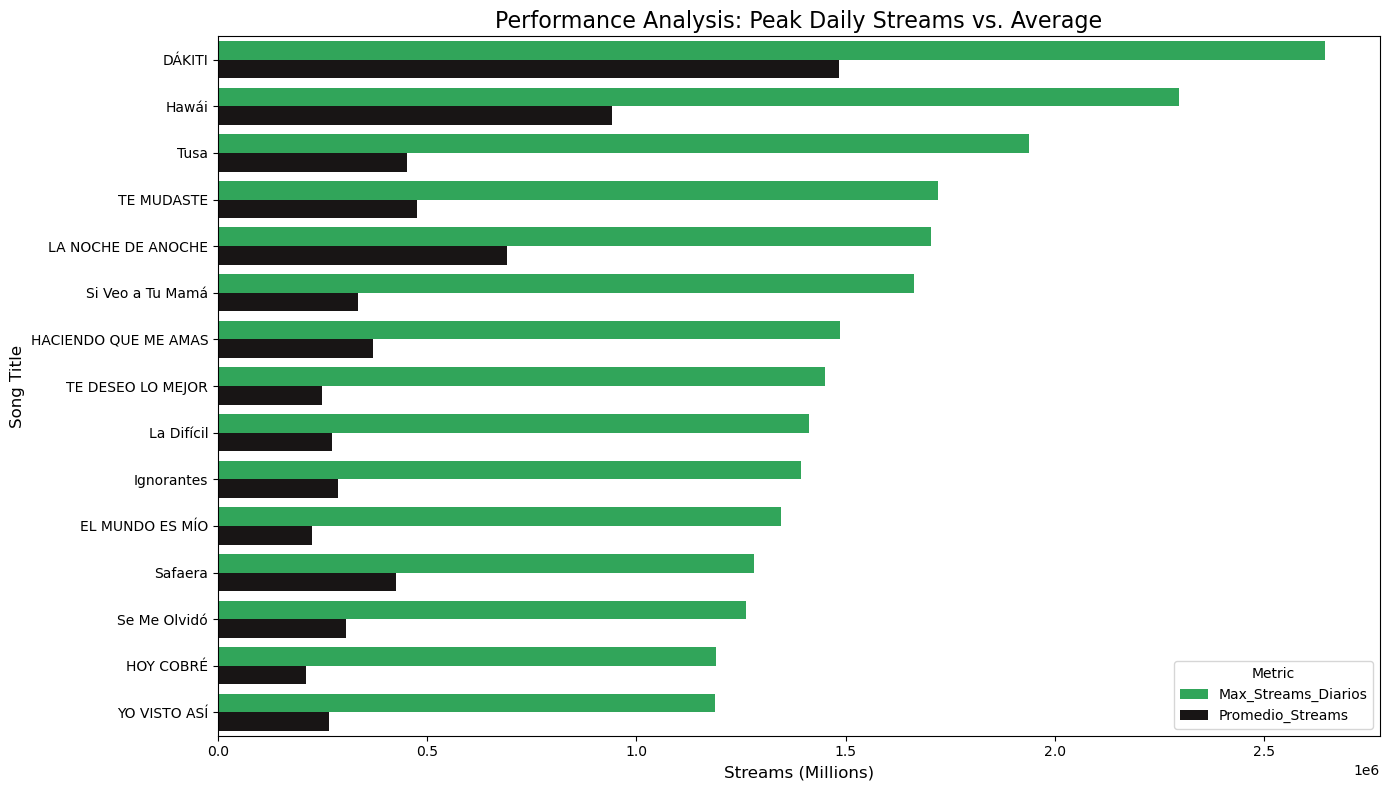

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
plt.figure(figsize=(14, 8))
df_plot = resultado_correlacionada.melt(id_vars='Cancion', value_vars=['Max_Streams_Diarios', 'Promedio_Streams'])

sns.barplot(data=df_plot, y='Cancion', x='value', hue='variable', palette=['#1DB954', '#191414'])

plt.title('Performance Analysis: Peak Daily Streams vs. Average', fontsize=16)
plt.xlabel('Streams (Millions)', fontsize=12)
plt.ylabel('Song Title', fontsize=12)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()